# XP Exercises: Flower Classification using CNN

This is a guided notebook for the exercises on the platform. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points appear only for key concepts that unlock intuition or transfer to other ML topics.


## What you will learn
- Building a CNN for multi class image classification
- Data loading and preprocessing with `image_dataset_from_directory`
- Image visualization techniques
- Model architecture design, compilation, and training
- Evaluating model performance with accuracy and loss plots


## What you will create
A CNN model that classifies 14 flower species.
All parts form one continuous exercise. Work through them sequentially.


## Dataset
**As stated in the exercises**  
Flower classification with 14 classes. Images are organized in class folders. A training and validation split may be provided. Images are resized to 256x256 in this notebook.

**PREFILLED info**  
This notebook expects the provided zip file to be available. The code below extracts it and locates the dataset root automatically.


In [4]:
# PREFILLED: just execute
import os, sys, zipfile, shutil, glob, math, json, random
from pathlib import Path

DATA_ZIP = Path("./Flower Classification.zip")
EXTRACT_DIR = Path("./data/flower_data")

# Clean extract dir if re-running
if EXTRACT_DIR.exists():
    pass  # avoid deleting in case you added files; delete manually if needed
else:
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

# Extract if a zip is present and not already extracted
if DATA_ZIP.exists():
    # Heuristically decide to extract once
    marker = EXTRACT_DIR / ".extracted"
    if not marker.exists():
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(EXTRACT_DIR)
        marker.write_text("ok")
        print("Extracted:", DATA_ZIP.name, "->", EXTRACT_DIR)
    else:
        print("Already extracted. Skipping.")
else:
    print("Zip file not found at", DATA_ZIP)

# Find candidate dataset roots: a dir with >= 10 subdirs assumed as classes, or contains train/val
def list_dirs(p):
    return [d for d in Path(p).iterdir() if d.is_dir()]

candidates = []
for root, dirs, files in os.walk(EXTRACT_DIR):
    if len([d for d in Path(root).iterdir() if Path(d).is_dir()]) >= 10:
        candidates.append(Path(root))
    if "train" in [d.name.lower() for d in list_dirs(root)] and "val" in [d.name.lower() for d in list_dirs(root)]:
        candidates.append(Path(root))

candidates = sorted(set(candidates))
print("Candidate dataset roots:", [str(c) for c in candidates][:5])

Extracted: Flower Classification.zip -> data/flower_data
Candidate dataset roots: ['data/flower_data/Data', 'data/flower_data/Data/train', 'data/flower_data/Data/val']


## Part 1. Data exploration and visualization

**As stated in the exercises**  
Load the dataset using `image_dataset_from_directory`. Print number of images per class. Modify `visualize_images` to show a 3x3 grid for each class with the class name as the grid title. Analyze challenges you anticipate when classifying the flowers such as similar colors or shapes and intra class variation.


**Guidance**  
If a `train` or `val` folder exists, use them. Otherwise create a split from a single root with `validation_split` and `subset`. Images are resized to 256x256 RGB.


> **IMPORTANT:** we fix a low resultion for images in IMG_SIZE=(32,32) for faster training, however you can change it if you want to test out other resolutions

In [5]:
# PREFILLED: just execute
import tensorflow as tf
from tensorflow.keras import layers

IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

def detect_layout(root: Path):
    root = Path(root)
    sub = [d.name.lower() for d in root.iterdir() if d.is_dir()]
    if "train" in sub and "val" in sub:
        return "provided_split", root
    return "single_root", root

# Choose a root
if 'candidates' in globals() and len(candidates) > 0:
    DS_ROOT = candidates[0]
else:
    DS_ROOT = EXTRACT_DIR  # fallback

layout, base = detect_layout(DS_ROOT)
print("Layout:", layout, "Base:", base)

Layout: provided_split Base: data/flower_data/Data


In [6]:
# PREFILLED: just execute
if layout == "provided_split":
    train_dir = next((p for p in base.iterdir() if p.name.lower()=="train"))
    val_dir   = next((p for p in base.iterdir() if p.name.lower()=="val"))
    train_ds = tf.keras.utils.image_dataset_from_directory(
        train_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        val_dir, image_size=IMG_SIZE, batch_size=BATCH_SIZE, seed=SEED, label_mode="int"
    )
else:
    train_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="training", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        base, validation_split=0.2, subset="validation", seed=SEED,
        image_size=IMG_SIZE, batch_size=BATCH_SIZE, label_mode="int"
    )

class_names = train_ds.class_names
num_classes = len(class_names)
print("Classes:", num_classes, class_names)

# Cache and prefetch
def prepare(ds):
    return ds.cache().prefetch(AUTOTUNE)

train_ds = prepare(train_ds)
val_ds = prepare(val_ds)

Found 13642 files belonging to 14 classes.
Found 98 files belonging to 14 classes.
Classes: 14 ['astilbe', 'bellflower', 'black_eyed_susan', 'calendula', 'california_poppy', 'carnation', 'common_daisy', 'coreopsis', 'dandelion', 'iris', 'rose', 'sunflower', 'tulip', 'water_lily']


In [7]:
# PREFILLED: just execute — count images per class by scanning directory
from collections import Counter
import os

def count_images_per_class(root):
    counts = {}
    for cls in class_names:
        # find folder named like cls at any depth under base
        matches = list(Path(base).rglob(cls))
        if matches:
            folder = matches[0]
            img_count = sum(1 for p in folder.rglob("*") if p.suffix.lower() in {".jpg",".jpeg",".png",".bmp",".gif"})
            counts[cls] = img_count
        else:
            counts[cls] = None
    return counts

base = "/content/data/flower_data/Data/train"
counts = count_images_per_class(base)
counts

{'astilbe': 726,
 'bellflower': 872,
 'black_eyed_susan': 986,
 'calendula': 1011,
 'california_poppy': 1021,
 'carnation': 924,
 'common_daisy': 978,
 'coreopsis': 1035,
 'dandelion': 1038,
 'iris': 1041,
 'rose': 986,
 'sunflower': 1013,
 'tulip': 1034,
 'water_lily': 977}

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# To-Do: implement visualize_images to display a 3x3 grid for each class
# Hints:
def visualize_images(dataset, class_names, per_class=9):
    # iterate batches, collect images by label until you have 9 per class
    collected_images = {cls: [] for cls in class_names}
    counts = {cls: 0 for cls in class_names}

    for images, labels in dataset:
        for i in range(images.shape[0]):
            label_idx = labels[i].numpy()
            class_name = class_names[label_idx]
            if counts[class_name] < per_class:
                collected_images[class_name].append(images[i].numpy())
                counts[class_name] += 1

        # Check if we have enough images for all classes
        if all(c == per_class for c in counts.values()):
            break

    # for each class, plot a 3x3 grid and set the figure suptitle to the class name
    for class_name in class_names:
        if not collected_images[class_name]:
            continue

        fig, axes = plt.subplots(3, 3, figsize=(8, 8))
        fig.suptitle(class_name, fontsize=16)
        axes = axes.flatten()

        for i, ax in enumerate(axes):
            if i < len(collected_images[class_name]):
                img = collected_images[class_name][i]
                # Assuming images are normalized to [0,1], convert to [0,255] for display if needed
                if img.max() <= 1.0:
                    img = (img * 255).astype(np.uint8)
                ax.imshow(img)
                ax.axis('off')
            else:
                ax.axis('off') # Hide empty subplots
        plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
        plt.show()


**To-Do:** After you implement `visualize_images`, run it on a small subset to verify class distributions visually.


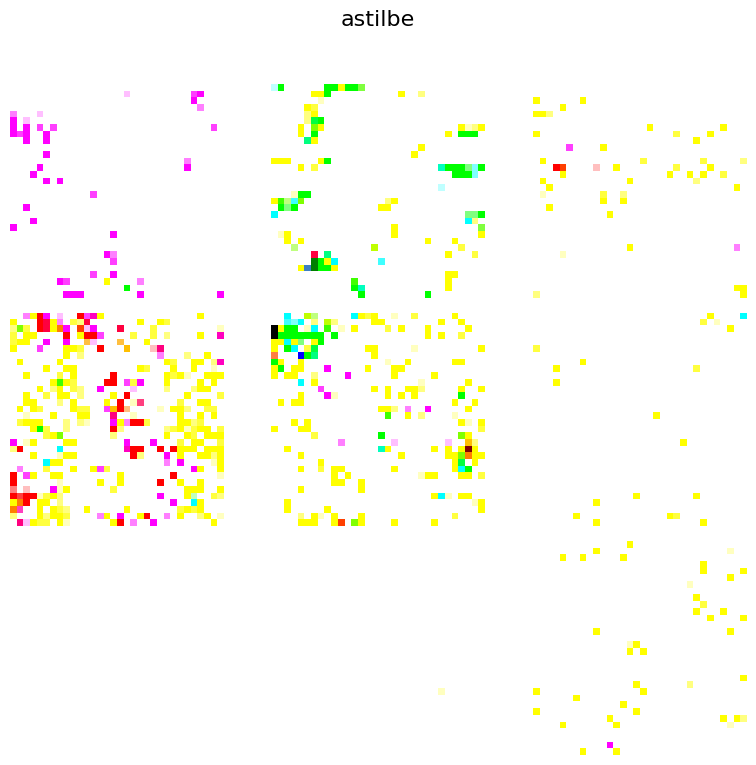

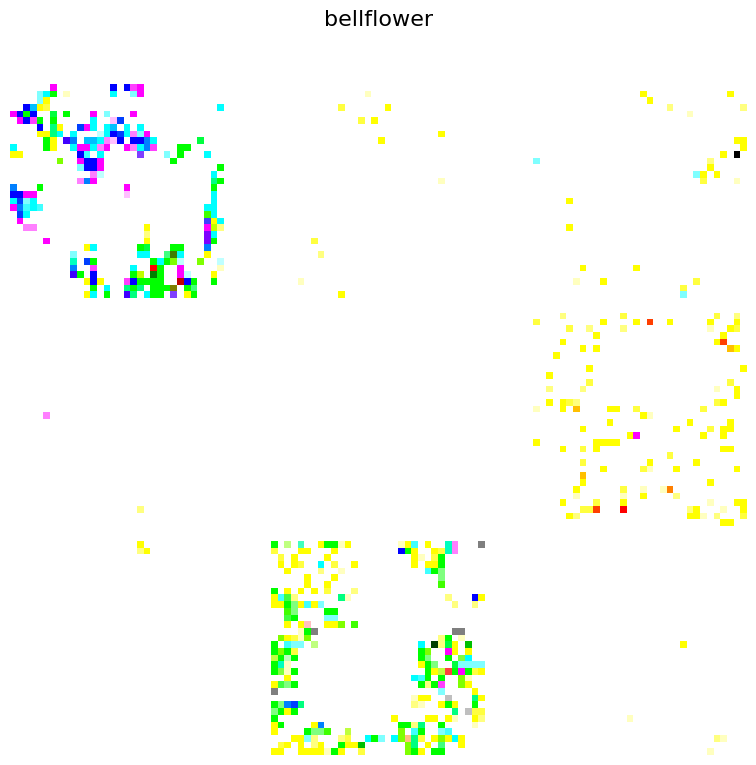

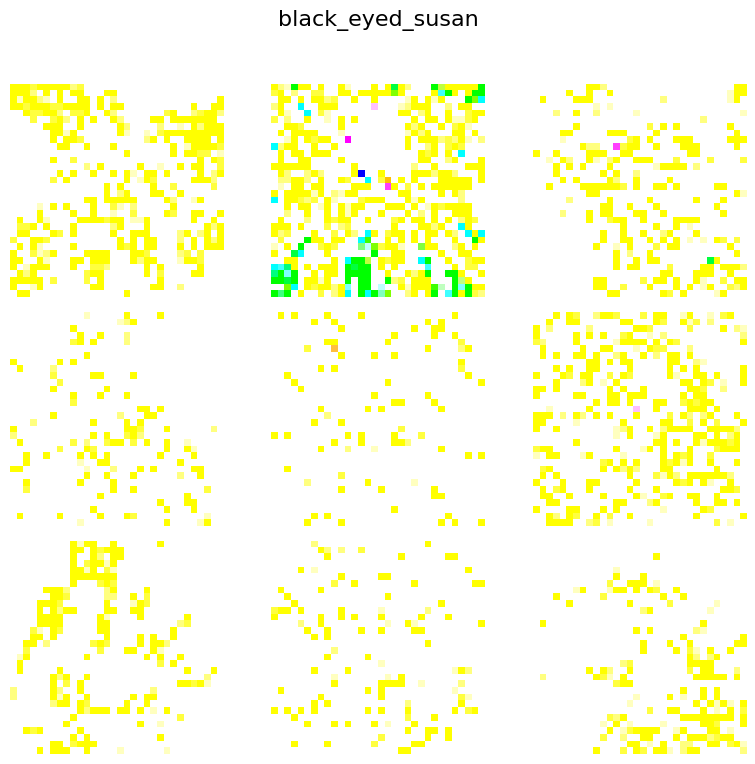

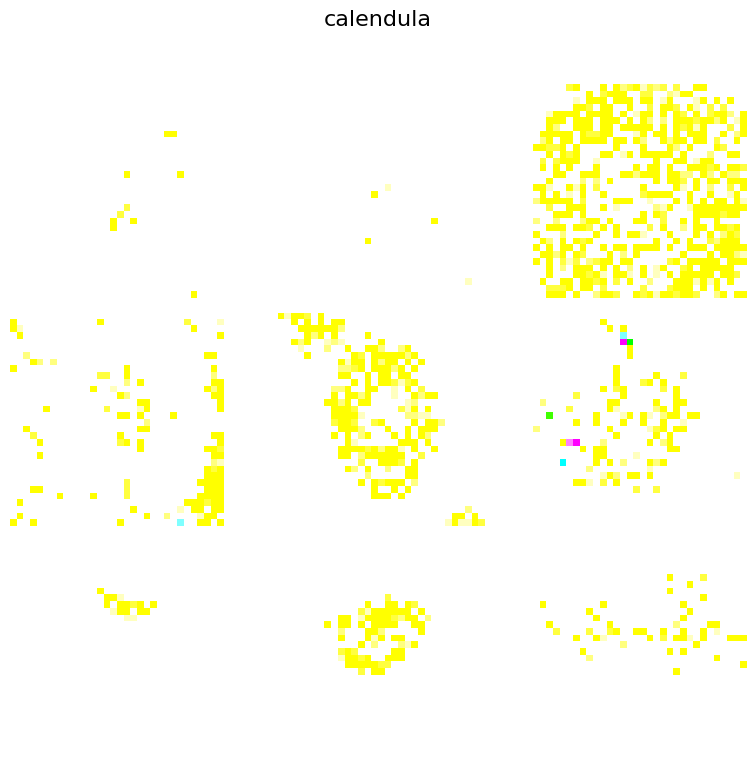

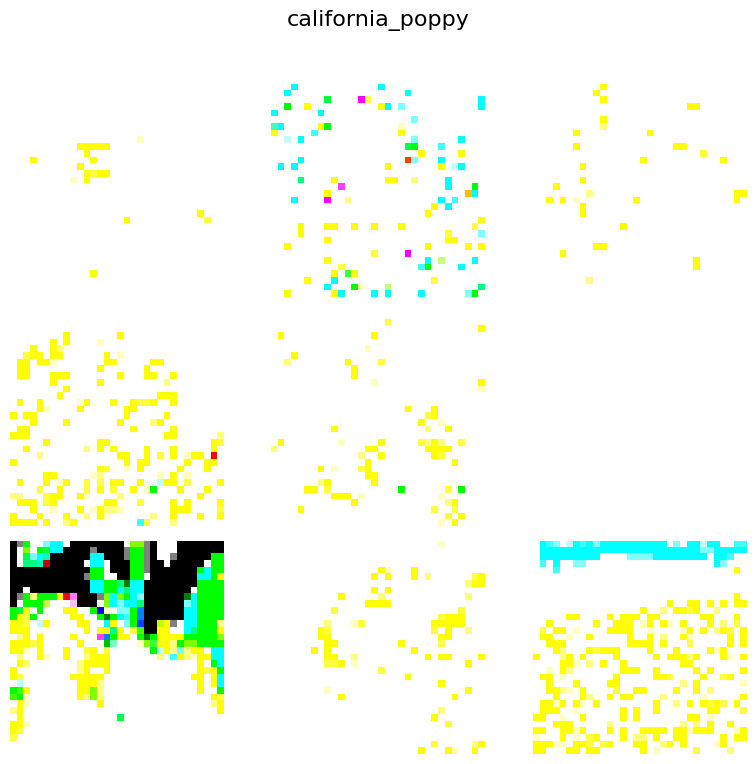

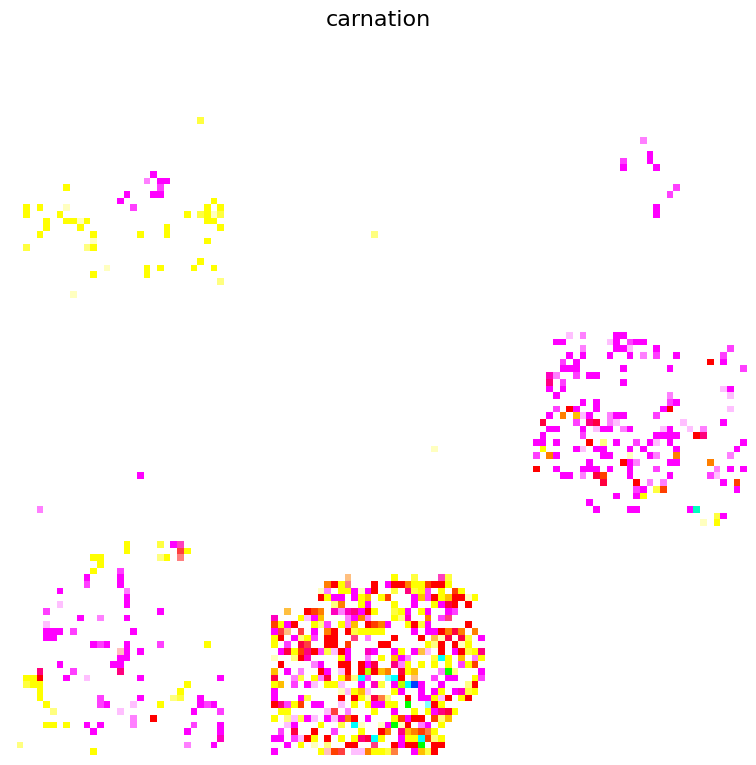

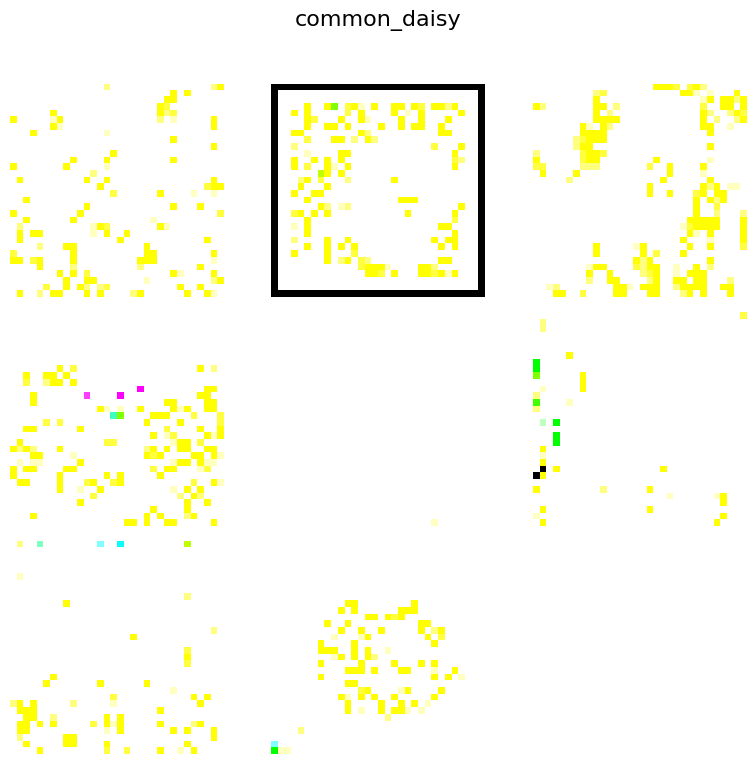

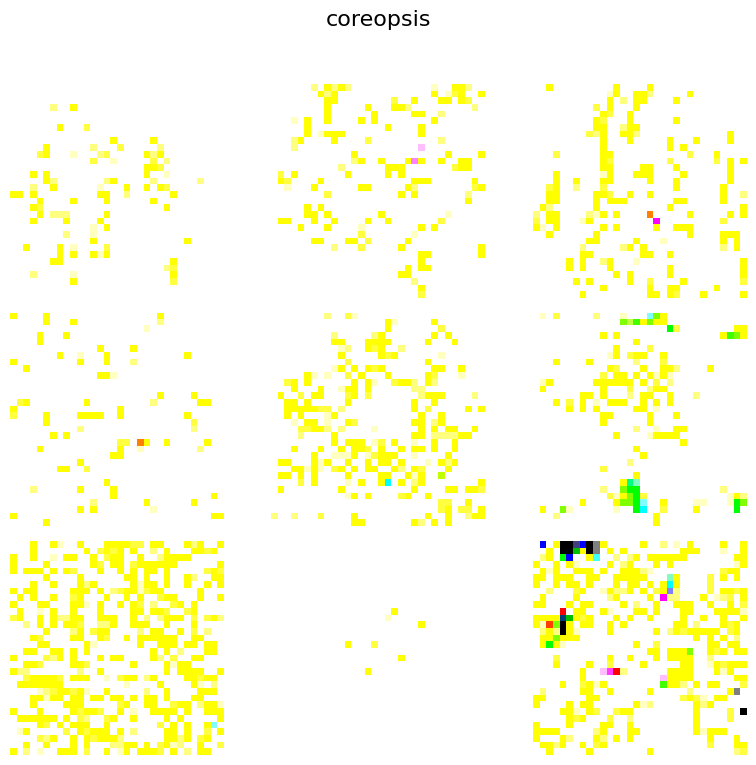

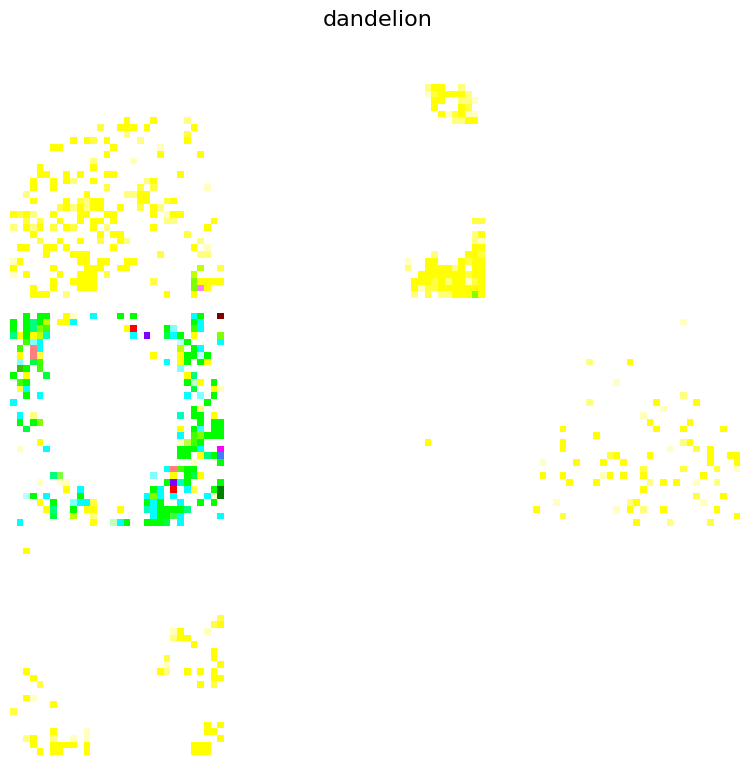

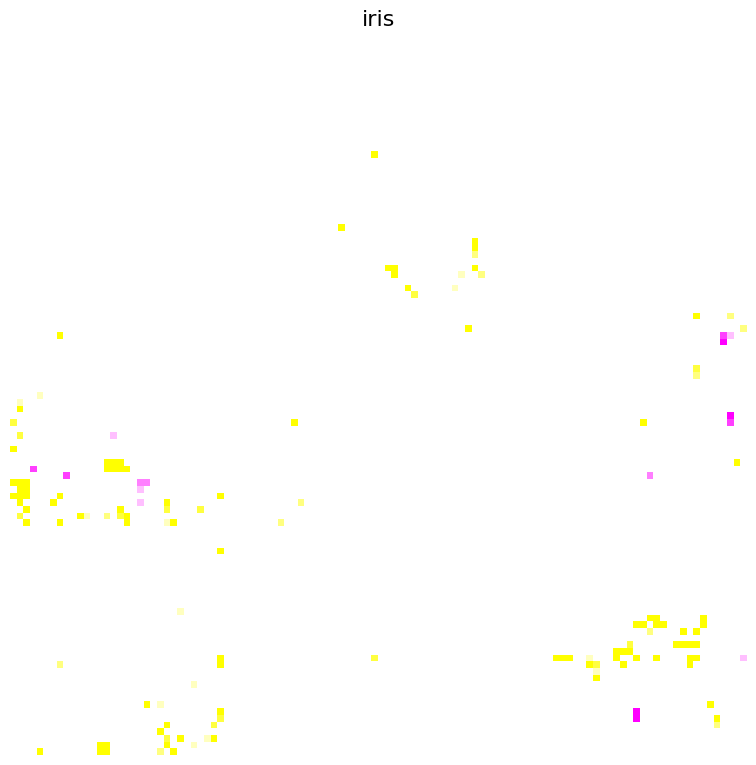

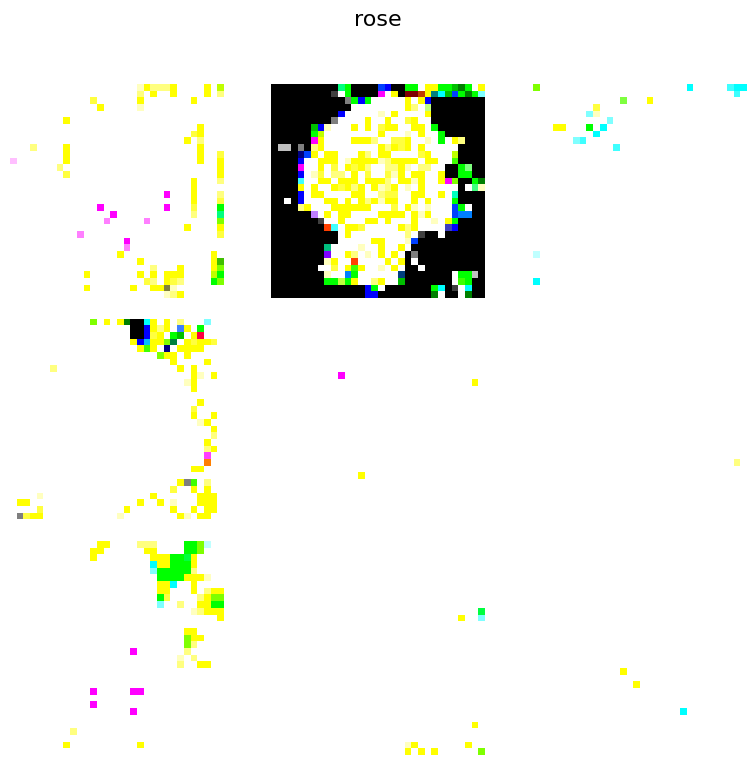

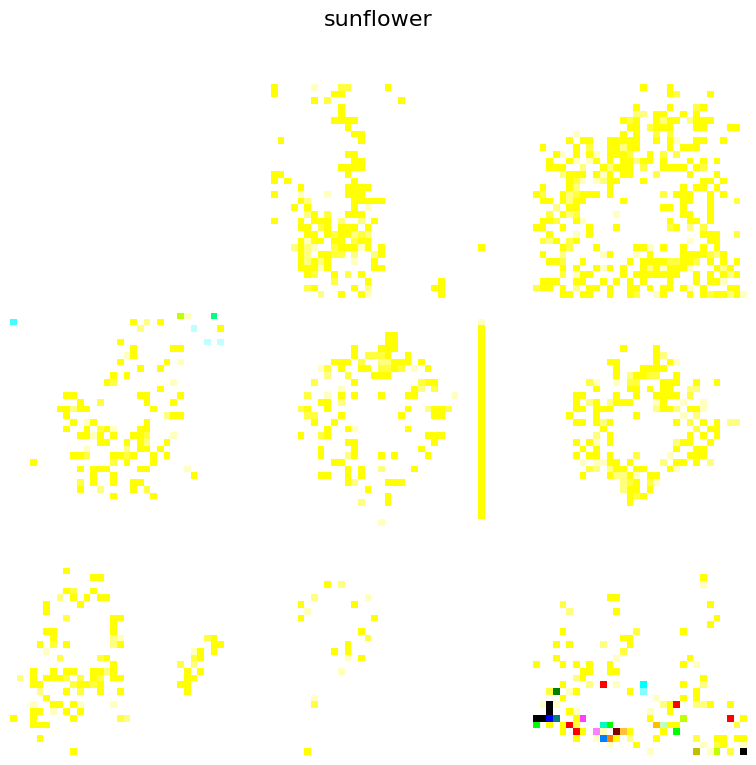

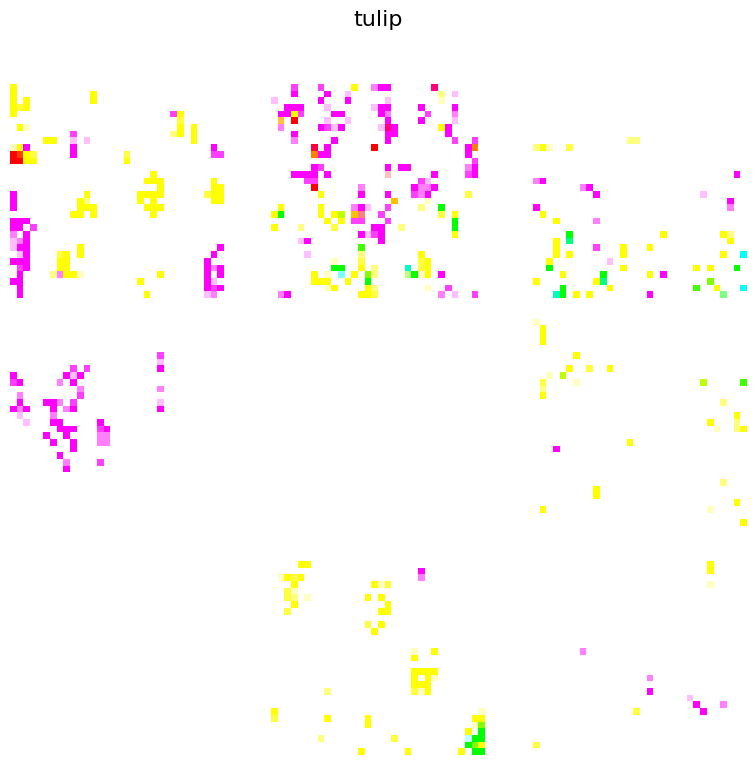

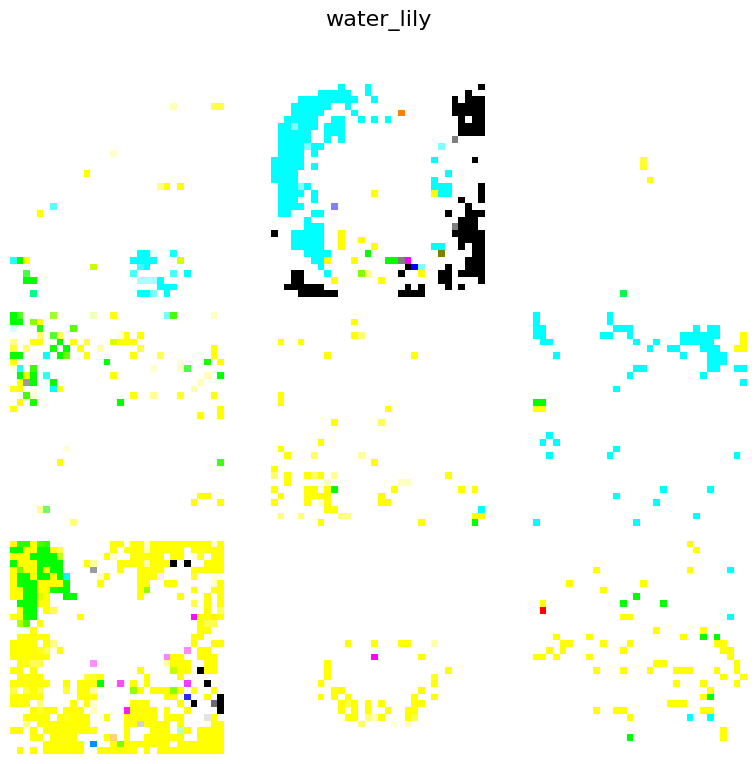

In [9]:
visualize_images(train_ds.take(10), class_names)

**To-Do (written):** Analyze expected challenges for classification in 4 to 6 sentences. Mention similar color palettes across species, intra class variation due to background and lighting, and class imbalance if present.


L'une des difficultés que pourrait rencontrer modèle peut être lié au couleur de certaine espèce. En effet, il y a des couleurs qui on a peut près les mêmes couleurs (sunflower et coréopsis). De plus on a un déséquilibre des classes. La fleur astilbe est l'espace la moins nombreuses contrairement au fleur comme coréopsis, dandelion, iris et tulip

**Learning point**  
Vision models learn features from texture, color, and shape. Dataset bias and imbalance can dominate results without careful preprocessing and evaluation.


## Part 2. Model architecture design

**As stated in the exercises**  
Start from the provided model. Experiment with the number of convolutional layers, filters, kernel sizes, max pooling layers. Try different dense layers and dropout. Consider Batch Normalization. Justify your architectural choices.


In [10]:
# PREFILLED: just execute — baseline model scaffold
from tensorflow.keras import models

def build_baseline(num_classes):
    model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized
        layers.Conv2D(32, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(64, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, 3, padding="same", activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax")
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model

baseline = build_baseline(num_classes)
baseline.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 14)             │         1,806 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,326 (1.36 MB)

 Trainable params: 357,326 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# To-Do: create an improved architecture variant
# Suggestions:
# - Add BatchNormalization after Conv2D or Dense
# - Try kernel sizes 5x5 in early layers
# - Increase filters progressively 32->64->128->256
# - Adjust Dropout to 0.4
def build_variant(num_classes):
   model = models.Sequential([
        layers.Input(shape=(*IMG_SIZE, 3)),
        layers.Rescaling(1./255),  # safety if datasets were not normalized

        #Bloc 1
        layers.Conv2D(32, (5,5), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        #Bloc 2
        layers.Conv2D(64, (5,5), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        #Bloc 3
        layers.Conv2D(128, (5,5), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        # Bloc 4
        layers.Conv2D(256, (3,3), padding="same", activation="relu"),
        layers.BatchNormalization(),
        layers.MaxPooling2D(),

        layers.Flatten(),


        layers.Dense(256, activation="relu"),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(num_classes, activation="softmax")
    ])
   model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
   return model
model_variant = build_variant(num_classes)
model_variant.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 14)             │         3,598 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 822,734 (3.14 MB)

 Trainable params: 821,262 (3.13 MB)

 Non-trainable params: 1,472 (5.75 KB)

**To-Do (written):** Justify your chosen layers and parameters in 4 to 6 sentences. Refer to receptive field growth, normalization stabilizing training, and dropout for regularization.


L’architecture du réseau est basée sur des couches convolutionnelles, car elles sont particulièrement adaptées à l’extraction automatique de caractéristiques visuelles comme les bords, textures et formes. Le nombre de filtres augmente progressivement (32, 64, 128, 256) afin de permettre au modèle d’apprendre des représentations de plus en plus complexes au fur et à mesure de la profondeur. Les couches de pooling réduisent la taille des cartes de caractéristiques, ce qui diminue la complexité du modèle tout en conservant les informations essentielles. La Batch Normalization est utilisée pour stabiliser et accélérer l’entraînement, tandis que le Dropout (0,4) limite le surapprentissage en améliorant la généralisation. Enfin, la couche dense suivie d’un Softmax permet de combiner les caractéristiques extraites et de produire une distribution de probabilités pour la Classification multiclasse.

## Part 3. Hyperparameter tuning

**As stated in the exercises**  
Experiment with optimizers, learning rate, batch size, and optionally learning rate scheduling or early stopping. Track experiments and results. Report the best combination.


In [12]:
# PREFILLED: just execute — utilities for training and plotting
import time

def fit_model(model, train_ds, val_ds, epochs=5, callbacks=None):
    t0 = time.time()
    history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, callbacks=callbacks, verbose=2)
    dt = time.time() - t0
    return history, dt

def plot_curves(history, title="Training"):
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("accuracy", []), label="acc")
    plt.plot(history.history.get("val_accuracy", []), label="val_acc")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend(); plt.tight_layout(); plt.show()
    plt.figure(figsize=(6,4))
    plt.plot(history.history.get("loss", []), label="loss")
    plt.plot(history.history.get("val_loss", []), label="val_loss")
    plt.title(title); plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.tight_layout(); plt.show()

In [13]:
# To-Do: run a few experiments
# Example search space
opts = [
  ("adam", 1e-3, 32),
  ("adam", 5e-4, 32),
  ("rmsprop", 1e-3, 32),
  ("sgd", 1e-2, 64),
]
results = []
for opt_name, lr, batch in opts:
    # rebuild model each time
    model = build_baseline(num_classes)  # or your variant
    if opt_name == "adam":
        optimizer = tf.keras.optimizers.Adam(lr)
    elif opt_name == "rmsprop":
        optimizer = tf.keras.optimizers.RMSprop(lr)
    else:
        optimizer = tf.keras.optimizers.SGD(lr, momentum=0.9, nesterov=True)
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    cb = [tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)]
    hist, dur = fit_model(model, train_ds, val_ds, epochs=8, callbacks=cb)
    best_val = max(hist.history["val_accuracy"])
    results.append({"opt": opt_name, "lr": lr, "batch": batch, "best_val_acc": float(best_val), "time_s": round(dur,1)})
results

Epoch 1/8
427/427 - 40s - 94ms/step - accuracy: 0.3373 - loss: 1.8826 - val_accuracy: 0.4082 - val_loss: 1.5284
Epoch 2/8
427/427 - 34s - 79ms/step - accuracy: 0.5119 - loss: 1.4075 - val_accuracy: 0.5510 - val_loss: 1.2562
Epoch 3/8
427/427 - 29s - 69ms/step - accuracy: 0.5862 - loss: 1.2093 - val_accuracy: 0.6429 - val_loss: 1.0561
Epoch 4/8
427/427 - 29s - 69ms/step - accuracy: 0.6297 - loss: 1.0715 - val_accuracy: 0.6837 - val_loss: 0.9591
Epoch 5/8
427/427 - 42s - 99ms/step - accuracy: 0.6665 - loss: 0.9563 - val_accuracy: 0.7449 - val_loss: 0.8874
Epoch 6/8
427/427 - 29s - 69ms/step - accuracy: 0.7029 - loss: 0.8593 - val_accuracy: 0.7041 - val_loss: 0.8997
Epoch 7/8
427/427 - 41s - 96ms/step - accuracy: 0.7365 - loss: 0.7661 - val_accuracy: 0.6735 - val_loss: 0.9252
Epoch 8/8
427/427 - 30s - 69ms/step - accuracy: 0.7599 - loss: 0.6962 - val_accuracy: 0.7245 - val_loss: 0.8678
Epoch 1/8
427/427 - 32s - 76ms/step - accuracy: 0.3159 - loss: 1.9446 - val_accuracy: 0.4796 - val_loss:

[{'opt': 'adam',
  'lr': 0.001,
  'batch': 32,
  'best_val_acc': 0.7448979616165161,
  'time_s': 286.6},
 {'opt': 'adam',
  'lr': 0.0005,
  'batch': 32,
  'best_val_acc': 0.7244898080825806,
  'time_s': 275.4},
 {'opt': 'rmsprop',
  'lr': 0.001,
  'batch': 32,
  'best_val_acc': 0.6836734414100647,
  'time_s': 261.5},
 {'opt': 'sgd',
  'lr': 0.01,
  'batch': 64,
  'best_val_acc': 0.7448979616165161,
  'time_s': 273.4}]

**To-Do (written):** Report the best hyperparameters you found and briefly explain why they might work well for this dataset.


Dans notre test d'hyperparamètre, nous avons obtenu de meilleurs résultats, notamment de la part de l'optimiseur. Pour notre modèle, on a trouvé que c'est c'est l'optimiseur sgd qui a donné de meilleures performances. Bien que Adam donne pratique le même accuracy, sgd a un temps d'exécution plus cours

## Part 4. Data augmentation

**As stated in the exercises**  
Implement data augmentation using `ImageDataGenerator`. Explore rotation, flipping, zooming, shifting, and shearing. Determine which augmentations help most and explain why.


**Guidance**  
Since we used `image_dataset_from_directory` above, you can either:  
Option A. Rebuild input using `ImageDataGenerator.flow_from_directory` on the training directory.  
Option B. Keep the tf.data pipeline and apply Keras preprocessing layers such as `RandomFlip`, `RandomRotation`.  
The exercises asks for `ImageDataGenerator`, so Option A shows that path.


Found 10919 images belonging to 14 classes.
Found 2723 images belonging to 14 classes.
Epoch 1/8
342/342 - 46s - 134ms/step - accuracy: 0.0741 - loss: 2.6378 - val_accuracy: 0.0764 - val_loss: 2.6360
Epoch 2/8
342/342 - 44s - 128ms/step - accuracy: 0.0696 - loss: 2.6364 - val_accuracy: 0.0764 - val_loss: 2.6354
Epoch 3/8
342/342 - 43s - 127ms/step - accuracy: 0.0739 - loss: 2.6358 - val_accuracy: 0.0757 - val_loss: 2.6355
Epoch 4/8
342/342 - 43s - 126ms/step - accuracy: 0.0754 - loss: 2.6360 - val_accuracy: 0.0760 - val_loss: 2.6353
Epoch 5/8
342/342 - 48s - 140ms/step - accuracy: 0.0704 - loss: 2.6358 - val_accuracy: 0.0760 - val_loss: 2.6352
Epoch 6/8
342/342 - 43s - 127ms/step - accuracy: 0.0740 - loss: 2.6356 - val_accuracy: 0.0760 - val_loss: 2.6352
Epoch 7/8
342/342 - 48s - 140ms/step - accuracy: 0.0767 - loss: 2.6357 - val_accuracy: 0.0760 - val_loss: 2.6353
Epoch 8/8
342/342 - 43s - 127ms/step - accuracy: 0.0710 - loss: 2.6358 - val_accuracy: 0.0764 - val_loss: 2.6352


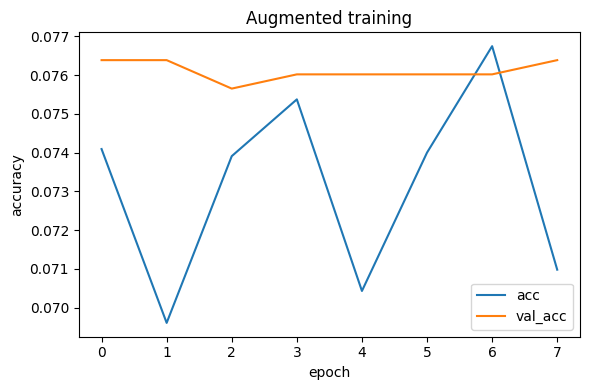

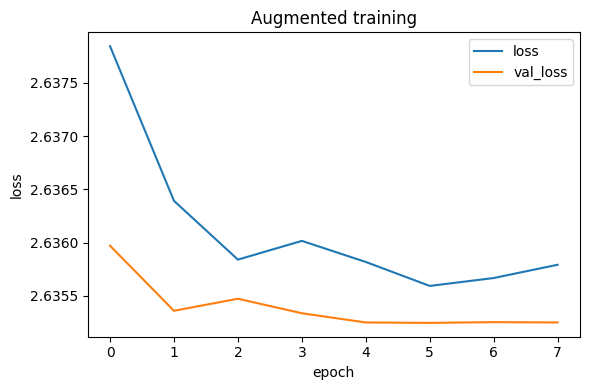

In [14]:
# To-Do: build an ImageDataGenerator pipeline (Option A)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_dir = next((p for p in Path(base).iterdir() if p.name.lower()=='train'), None)
if train_dir is None:
  train_dir = base  # if single root
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)
flow_train = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                        class_mode='sparse', subset='training', seed=SEED)
flow_val = datagen.flow_from_directory(train_dir, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
                                      class_mode='sparse', subset='validation', seed=SEED)
model_aug = build_baseline(num_classes)  # or your variant
hist_aug = model_aug.fit(flow_train, validation_data=flow_val, epochs=8, verbose=2)
plot_curves(hist_aug, title='Augmented training')

**Learning point**  
Augmentation encodes invariances like rotation and translation. It increases effective sample diversity which often reduces overfitting.


Les augmentations les plus efficaces pour le dataset sont la rotation, le zoom, le shift et l'horizontal flip, car elles reproduisent les variations naturelles de prise de vue (angle, distance, cadrage). Globalement, ces augmentations améliorent la généralisation en réduisant le surapprentissage et en rendant le modèle invariant aux conditions de capture des images.

## Part 5. Performance evaluation and analysis

**As stated in the exercises**  
Plot training and validation curves. Compute precision, recall, F1, and a confusion matrix. Visualize predictions on a test set and analyze misclassifications.


In [15]:
# PREFILLED: just execute — helpers for evaluation on a dataset
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

def collect_preds(model, ds):
    y_true = []
    y_prob = []
    for xb, yb in ds:
        pr = model.predict(xb, verbose=0)
        y_prob.append(pr)
        y_true.append(yb.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    if y_prob.ndim == 2 and y_prob.shape[1] > 1:
        y_pred = y_prob.argmax(axis=1)
    else:
        y_pred = (y_prob.ravel() >= 0.5).astype(int)
    return y_true, y_pred, y_prob

def plot_confusion(cm, labels):
    plt.figure(figsize=(6,6))
    plt.imshow(cm)
    plt.title("Confusion matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=90)
    plt.yticks(ticks, labels)
    plt.tight_layout()
    plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                  precision    recall  f1-score   support

         astilbe      0.000     0.000     0.000         7
      bellflower      0.000     0.000     0.000         7
black_eyed_susan      0.000     0.000     0.000         7
       calendula      0.000     0.000     0.000         7
california_poppy      0.000     0.000     0.000         7
       carnation      0.000     0.000     0.000         7
    common_daisy      0.000     0.000     0.000         7
       coreopsis      0.000     0.000     0.000         7
       dandelion      0.074     1.000     0.139         7
            iris      0.000     0.000     0.000         7
            rose      0.000     0.000     0.000         7
       sunflower      0.000     0.000     0.000         7
           tulip      0.000     0.000     0.000         7
      water_lily      0.000     0.000     0.000         7

        accuracy                          0.071        98
       macro avg      0.005     0.071     0.010        98
    weighted

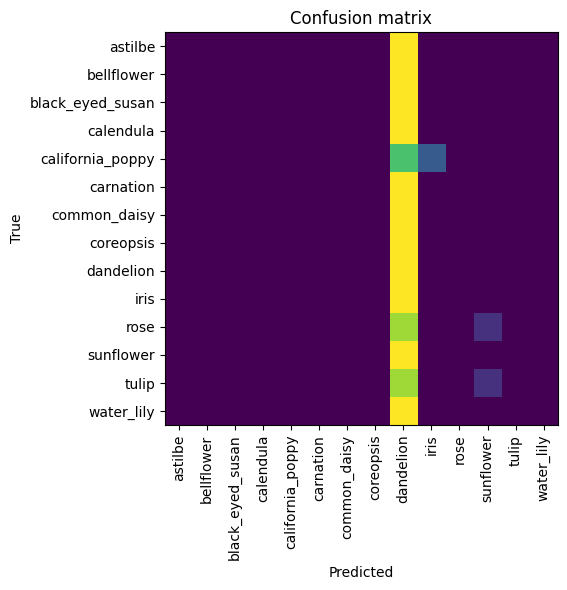

In [16]:
#To-Do: evaluate your best model on val_ds
best_model = model_aug or model_variant or baseline
y_true, y_pred, y_prob = collect_preds(best_model, val_ds)
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))
cm = confusion_matrix(y_true, y_pred)
plot_confusion(cm, class_names)

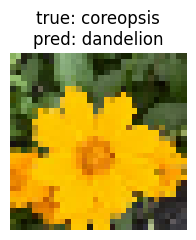

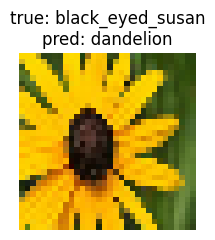

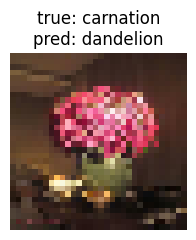

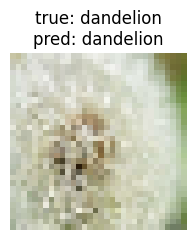

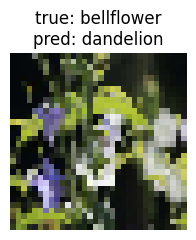

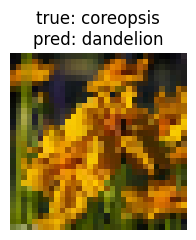

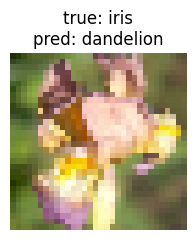

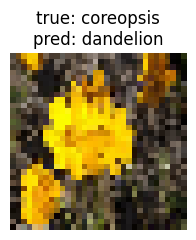

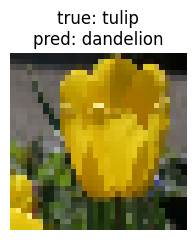

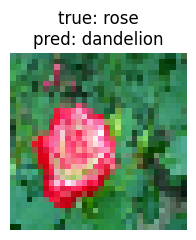

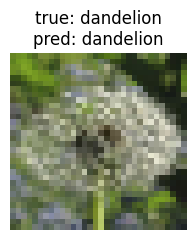

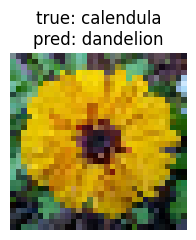

In [17]:
# To-Do: visualize a few predictions and inspect errors
import random
take = 12
imgs, labels = next(iter(val_ds.unbatch().batch(take)))
probs = best_model.predict(imgs, verbose=0)
preds = probs.argmax(axis=1)
for i in range(take):
    plt.figure(figsize=(2.5,2.5))
    plt.imshow(imgs[i].numpy().astype('uint8'))
    t = f"true: {class_names[int(labels[i])]}\npred: {class_names[int(preds[i])]}"
    plt.title(t)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

In [19]:
print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

                  precision    recall  f1-score   support

         astilbe      0.000     0.000     0.000         7
      bellflower      0.000     0.000     0.000         7
black_eyed_susan      0.000     0.000     0.000         7
       calendula      0.000     0.000     0.000         7
california_poppy      0.000     0.000     0.000         7
       carnation      0.000     0.000     0.000         7
    common_daisy      0.000     0.000     0.000         7
       coreopsis      0.000     0.000     0.000         7
       dandelion      0.074     1.000     0.139         7
            iris      0.000     0.000     0.000         7
            rose      0.000     0.000     0.000         7
       sunflower      0.000     0.000     0.000         7
           tulip      0.000     0.000     0.000         7
      water_lily      0.000     0.000     0.000         7

        accuracy                          0.071        98
       macro avg      0.005     0.071     0.010        98
    weighted

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**To-Do (written):** Identify classes that your model finds difficult. Explain possible causes such as similar morphology or color, or small sample counts.


Dans notre jeu de donnée, les fleures de dandelion sont les fleurs les plus prédite par le modèle, ce qui peut s"explique par le fait que d'abord c'est la fleur avec le plus grand éffectifs. De plus, cette fleur possède des morphologie différente (donc peut réssembler à d'autre fleur) raison pour laquelle le modèle prédit à tendance à prédire cette classe

## Part 6. Model saving and deployment (optional)

**As stated in the exercises**  
Save your trained model in `.h5` or SavedModel format. Optionally consider web or cloud deployment.


In [18]:
# To-Do: save your best model
best_model.save("./data/flower_cnn_savedmodel")  # SavedModel directory
best_model.save("./data/flower_cnn.h5")  # H5 file
print("Saved to ./data/")